In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anderas/car-consume/gas_station_orig.jpg
/kaggle/input/datasets/anderas/car-consume/measurements2.xlsx
/kaggle/input/datasets/anderas/car-consume/measurements.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/datasets/anderas/car-consume/measurements.csv")

# Exploratory Analysis

## Dataset samples & summary

In [4]:
df.head()

,distance,consume,speed,temp_inside,temp_outside,specials,gas_type,AC,rain,sun,refill liters,refill gas
0,28,5,26,"21,5",12,NaN,E10,0,0,0,45,E10
1,12,"4,2",30,"21,5",13,NaN,E10,0,0,0,NaN,NaN
2,"11,2","5,5",38,"21,5",15,NaN,E10,0,0,0,NaN,NaN
3,"12,9","3,9",36,"21,5",14,NaN,E10,0,0,0,NaN,NaN
4,"18,5","4,5",46,"21,5",15,NaN,E10,0,0,0,NaN,NaN


In [5]:
cols_to_fix = ['distance', 'consume', 'temp_inside', 'refill liters']

for col in cols_to_fix:
    df[col] = (
        df[col]
        .astype(str)               # paksa semua jadi string dulu
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance       388 non-null    float64
 1   consume        388 non-null    float64
 2   speed          388 non-null    int64  
 3   temp_inside    376 non-null    float64
 4   temp_outside   388 non-null    int64  
 5   specials       93 non-null     object 
 6   gas_type       388 non-null    object 
 7   AC             388 non-null    int64  
 8   rain           388 non-null    int64  
 9   sun            388 non-null    int64  
 10  refill liters  13 non-null     float64
 11  refill gas     13 non-null     object 
dtypes: float64(4), int64(5), object(3)
memory usage: 36.5+ KB


## Descriptive statistics

In [7]:
df.describe()

,distance,consume,speed,temp_inside,temp_outside,AC,rain,sun,refill liters
count,388.000000,388.000000,388.000000,376.000000,388.000000,388.000000,388.000000,388.000000,13.000000
mean,19.652835,4.912371,41.927835,21.929521,11.358247,0.077320,0.123711,0.082474,37.115385
std,22.667837,1.033172,13.598524,1.010455,6.991542,0.267443,0.329677,0.275441,8.587282
min,1.300000,3.300000,14.000000,19.000000,-5.000000,0.000000,0.000000,0.000000,10.000000
25%,11.800000,4.300000,32.750000,21.500000,7.000000,0.000000,0.000000,0.000000,37.600000
50%,14.600000,4.700000,40.500000,22.000000,10.000000,0.000000,0.000000,0.000000,38.000000
75%,19.000000,5.300000,50.000000,22.500000,16.000000,0.000000,0.000000,0.000000,39.000000
max,216.100000,12.200000,90.000000,25.500000,31.000000,1.000000,1.000000,1.000000,45.000000


In [8]:
df.describe(include="object")

,specials,gas_type,refill gas
count,93,388,13
unique,12,2,2
top,rain,SP98,SP98
freq,32,228,8


## Unique value of categorical value

In [9]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 50)

Column: specials
[nan 'AC rain' 'AC' 'rain' 'snow' 'AC snow' 'half rain half sun' 'sun'
 'AC sun' 'sun ac' 'ac' 'AC Sun' 'ac rain']
--------------------------------------------------
Column: gas_type
['E10' 'SP98']
--------------------------------------------------
Column: refill gas
['E10' nan 'SP98']
--------------------------------------------------


## Missing value %

In [10]:
missing = df.isnull().mean().sort_values(ascending=False)
missing

refill gas       0.966495
refill liters    0.966495
specials         0.760309
temp_inside      0.030928
speed            0.000000
consume          0.000000
distance         0.000000
temp_outside     0.000000
AC               0.000000
gas_type         0.000000
sun              0.000000
rain             0.000000
dtype: float64

## Numerical feature distribution

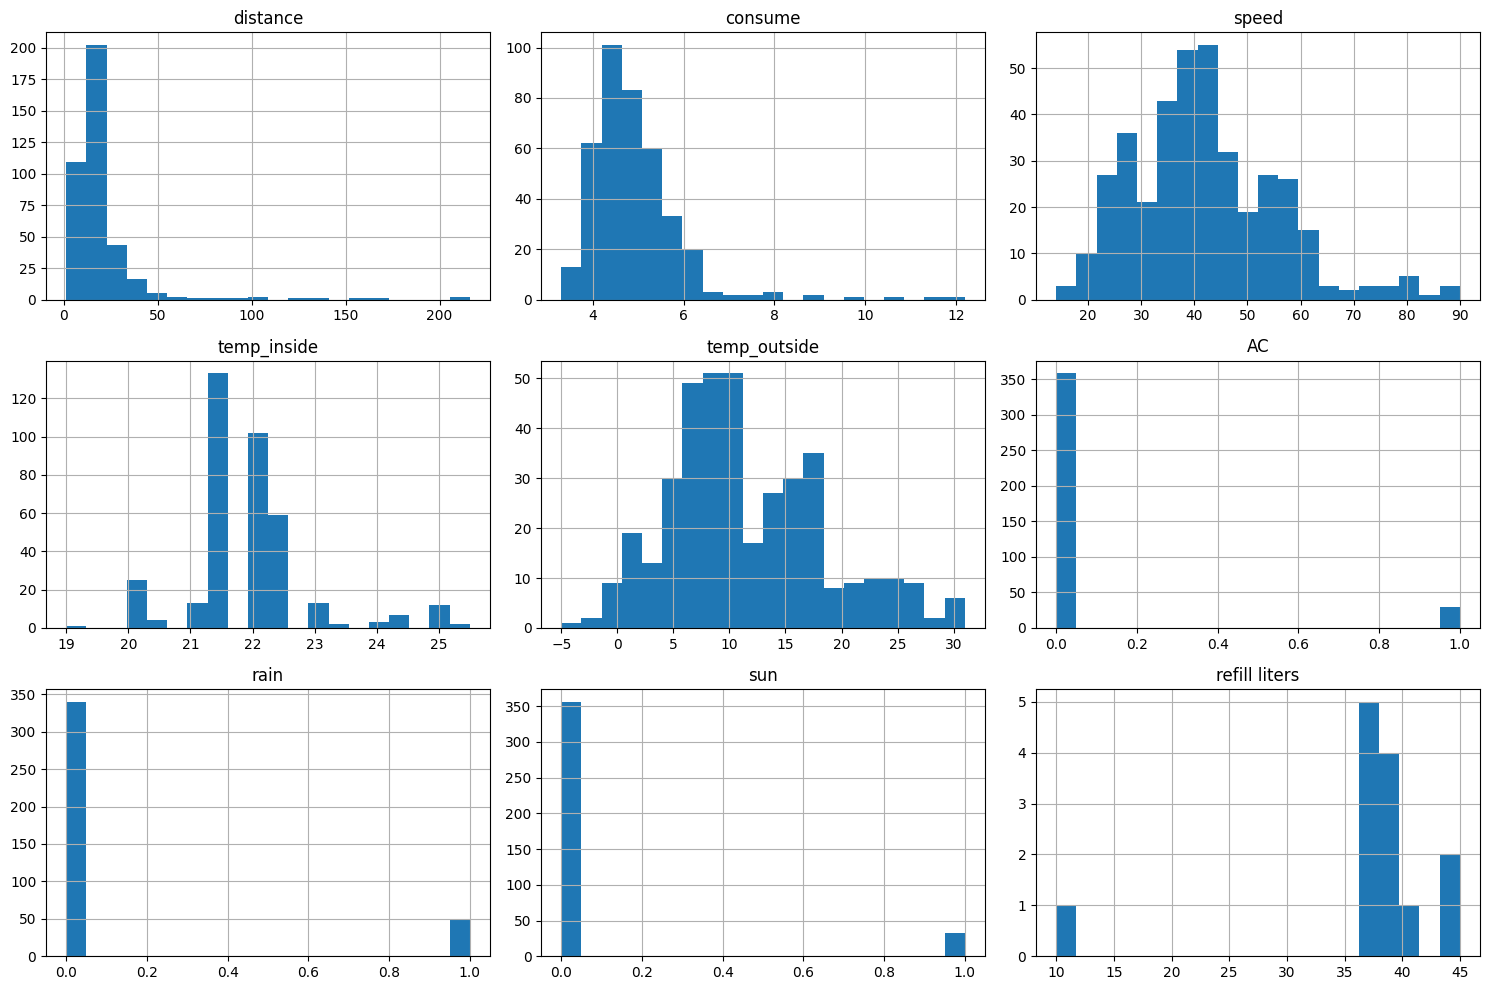

In [11]:
# Ambil hanya kolom numerik
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Plot semua dalam 1 cell
df_numeric.hist(figsize=(15, 10), bins=20)

plt.tight_layout()
plt.show()

## E10 & SP98 comparrison

In [12]:
# simple approach : Average consume based gas type
df.groupby('gas_type')['consume'].mean()

gas_type
E10     4.931250
SP98    4.899123
Name: consume, dtype: float64

In [13]:
df.groupby('gas_type')['consume'].agg(['mean', 'count', 'std'])

,mean,count,std
gas_type,,,
E10,4.931250,160,0.900956
SP98,4.899123,228,1.118408


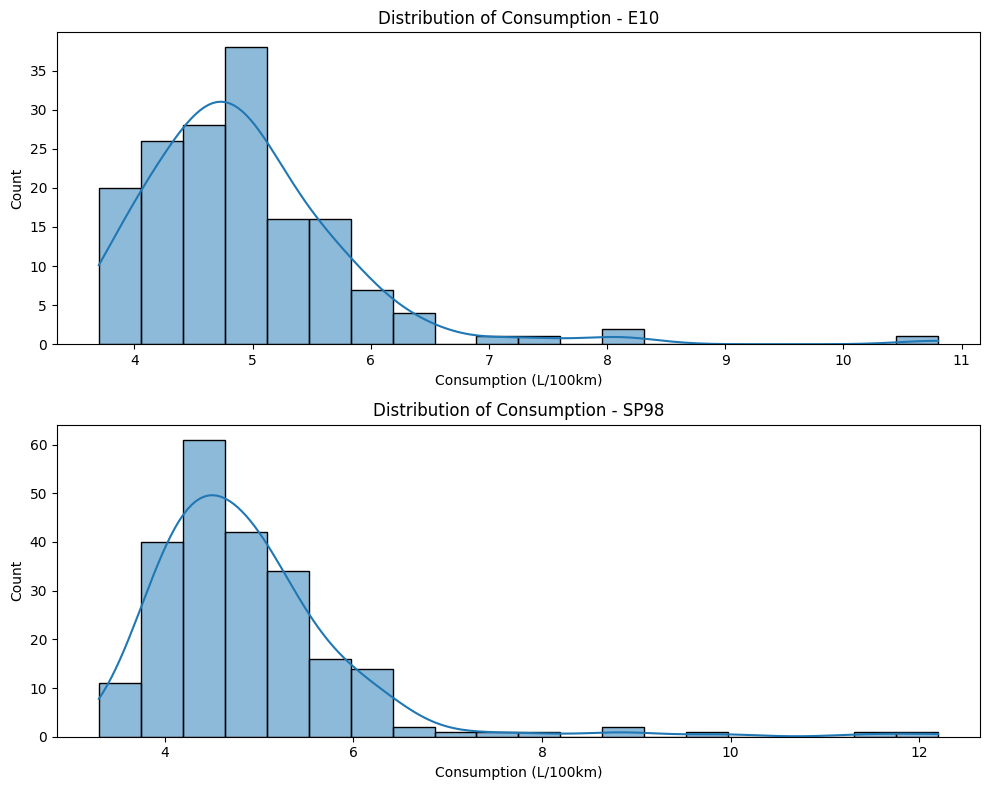

In [14]:
gas_types = df['gas_type'].unique()

plt.figure(figsize=(10, 4 * len(gas_types)))

for i, gas in enumerate(gas_types, 1):
    plt.subplot(len(gas_types), 1, i)
    
    subset = df[df['gas_type'] == gas]
    sns.histplot(subset['consume'], bins=20, kde=True)
    
    plt.title(f'Distribution of Consumption - {gas}')
    plt.xlabel('Consumption (L/100km)')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

<Axes: xlabel='distance', ylabel='consume'>

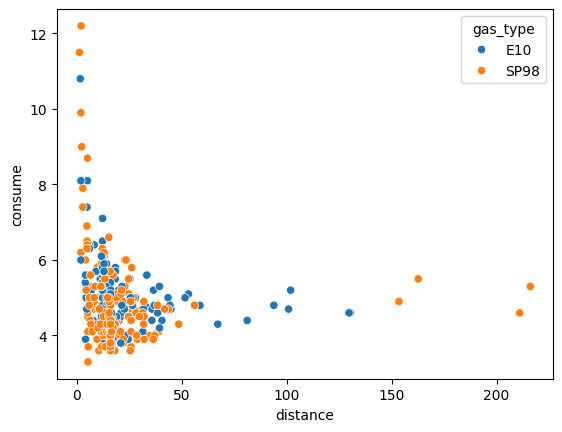

In [15]:
sns.scatterplot(data=df, x='distance', y='consume', hue='gas_type')

In [16]:
df['trip_type'] = df['distance'].apply(lambda x: 'short' if x < 20 else 'long')
df.groupby(['trip_type','gas_type'])['consume'].mean()

trip_type  gas_type
long       E10         4.741304
           SP98        4.591489
short      E10         5.007895
           SP98        4.979006
Name: consume, dtype: float64

## Distance & Consume correlation

In [17]:
df[['distance', 'consume']].corr()

,distance,consume
distance,1.000000,-0.128967
consume,-0.128967,1.000000


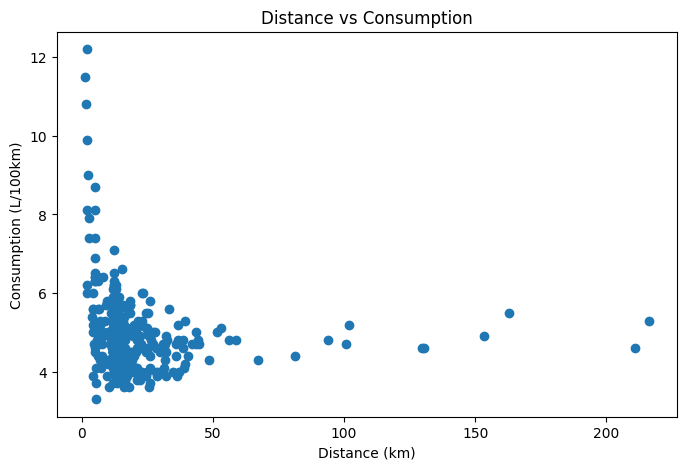

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['distance'], df['consume'])
plt.xlabel('Distance (km)')
plt.ylabel('Consumption (L/100km)')
plt.title('Distance vs Consumption')
plt.show()

## Correlation matrix

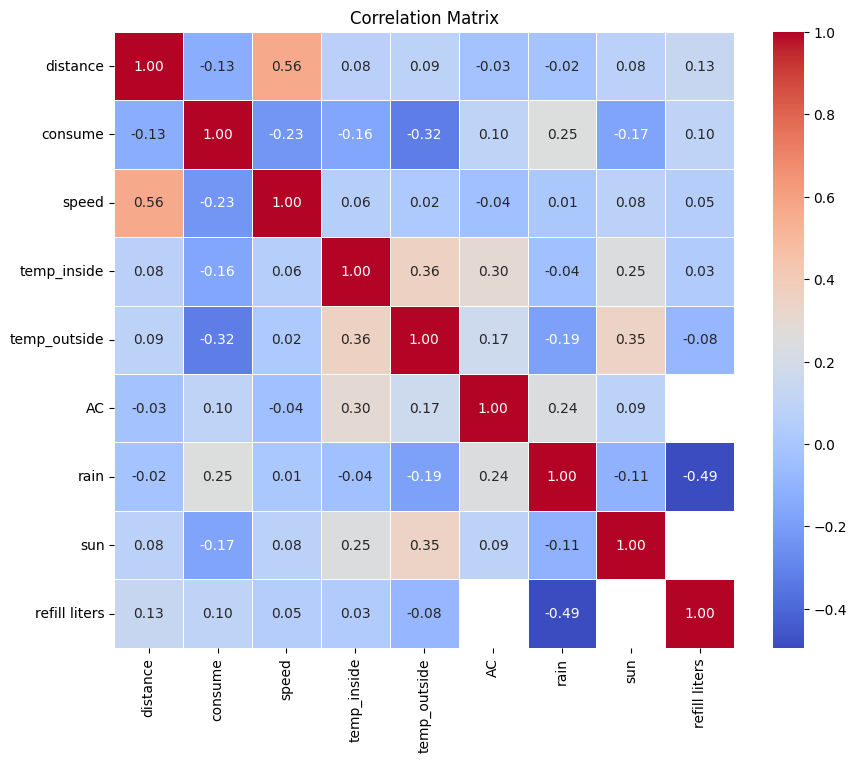

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## Summary 
1. **distance** : Numerical feature, no missing feature (positive skewed)
2. **consume** : Numerical feature, no missing value (positive skewed)
3. **speed** : Numerical feature, no missing value (positive skewed)
4. **temp_inside** : Numerical feature, has missing value (~3%)
5. **temp_outside** : Numerical feature, no missing value
6. **specials** : Categorical feature, has a lot of missing values (**~76%**)
7. **gas_type** : Categorical feature, no missing value
8. **AC** : Categorical feature (as binary), no missing value
9. **rain** : Categorical feature (as binary), no missing value
10. **sun** : Categorical feature (as binary), no missing value
11. **refill liters** : Has a lot of missing values (**~96%**)
12. **refill gas** : Has a lot of missing values (**~96%**)

In [20]:
# 0   distance       388 non-null    float64
#  1   consume        388 non-null    float64
#  2   speed          388 non-null    int64  
#  3   temp_inside    376 non-null    float64
#  4   temp_outside   388 non-null    int64  
#  5   specials       93 non-null     object 
#  6   gas_type       388 non-null    object 
#  7   AC             388 non-null    int64  
#  8   rain           388 non-null    int64  
#  9   sun            388 non-null    int64  
#  10  refill liters  13 non-null     float64
#  11  refill gas     13 non-null     object

# Feature Engineering

## Imputation - Temp. Inside

In [21]:
df['temp_inside'] = df['temp_inside'].fillna(df['temp_inside'].median())

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance       388 non-null    float64
 1   consume        388 non-null    float64
 2   speed          388 non-null    int64  
 3   temp_inside    388 non-null    float64
 4   temp_outside   388 non-null    int64  
 5   specials       93 non-null     object 
 6   gas_type       388 non-null    object 
 7   AC             388 non-null    int64  
 8   rain           388 non-null    int64  
 9   sun            388 non-null    int64  
 10  refill liters  13 non-null     float64
 11  refill gas     13 non-null     object 
 12  trip_type      388 non-null    object 
dtypes: float64(4), int64(5), object(4)
memory usage: 39.5+ KB


# Model building : Linear Model

In [23]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [24]:
df.head()

,distance,consume,speed,temp_inside,temp_outside,specials,gas_type,AC,rain,sun,refill liters,refill gas,trip_type
0,28.0,5.0,26,21.5,12,NaN,E10,0,0,0,45.0,E10,long
1,12.0,4.2,30,21.5,13,NaN,E10,0,0,0,NaN,NaN,short
2,11.2,5.5,38,21.5,15,NaN,E10,0,0,0,NaN,NaN,short
3,12.9,3.9,36,21.5,14,NaN,E10,0,0,0,NaN,NaN,short
4,18.5,4.5,46,21.5,15,NaN,E10,0,0,0,NaN,NaN,short
